In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image, ImageDraw
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from matplotlib import pyplot as plt

In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=(256, 256), transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size
        self.transform = transform
        self.img_files = sorted(os.listdir(img_dir))
        self.label_files = sorted(os.listdir(label_dir))

        # Preload all images and masks into memory
        self.data = []
        for img_file, label_file in zip(self.img_files, self.label_files):
            # Load image
            img_path = os.path.join(self.img_dir, img_file)
            image = Image.open(img_path).convert("RGB")
            image = image.resize(self.img_size)

            # Load label and create binary mask
            label_path = os.path.join(self.label_dir, label_file)
            with open(label_path, 'r') as f:
                label_data = f.readlines()

            mask = Image.new("L", self.img_size, 0)  # Create a blank mask
            draw = ImageDraw.Draw(mask)

            for line in label_data:
                parts = line.strip().split()
                class_id = int(parts[0])  # Class ID (not used here)
                coords = list(map(float, parts[1:]))
                coords = [(x * self.img_size[0], y * self.img_size[1]) for x, y in zip(coords[::2], coords[1::2])]
                draw.polygon(coords, outline=1, fill=1)

            mask = np.array(mask)

            # Store preloaded data
            self.data.append((image, mask))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Retrieve preloaded image and mask
        image, mask = self.data[idx]

        # Apply transforms
        if self.transform:
            image = self.transform(image)
            mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)  # Add channel dimension

        return image, mask

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.encoder1 = conv_block(in_channels, 64)
        self.encoder2 = conv_block(64, 128)
        self.encoder3 = conv_block(128, 256)
        self.encoder4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder4 = conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = conv_block(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))
        enc4 = self.encoder4(self.pool(enc3))

        # Bottleneck
        bottleneck = self.bottleneck(self.pool(enc4))

        # Decoder
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)

        return self.final_conv(dec1)

In [ ]:
class SmallUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_c=28, dropout=0.1):
        super(SmallUNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Dropout2d(dropout)
            )

        self.encoder1 = conv_block(in_channels, base_c)
        self.encoder2 = conv_block(base_c, base_c * 2)
        self.encoder3 = conv_block(base_c * 2, base_c * 4)
        self.encoder4 = conv_block(base_c * 4, base_c * 8)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = conv_block(base_c * 8, base_c * 16)

        self.upconv4 = nn.ConvTranspose2d(base_c * 16, base_c * 8, kernel_size=2, stride=2)
        self.decoder4 = conv_block(base_c * 16, base_c * 8)
        self.upconv3 = nn.ConvTranspose2d(base_c * 8, base_c * 4, kernel_size=2, stride=2)
        self.decoder3 = conv_block(base_c * 8, base_c * 4)
        self.upconv2 = nn.ConvTranspose2d(base_c * 4, base_c * 2, kernel_size=2, stride=2)
        self.decoder2 = conv_block(base_c * 4, base_c * 2)
        self.upconv1 = nn.ConvTranspose2d(base_c * 2, base_c, kernel_size=2, stride=2)
        self.decoder1 = conv_block(base_c * 2, base_c)

        self.final_conv = nn.Conv2d(base_c, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))
        enc4 = self.encoder4(self.pool(enc3))

        # Bottleneck
        bottleneck = self.bottleneck(self.pool(enc4))

        # Decoder
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)

        return self.final_conv(dec1)

In [ ]:
# print the number of parameters in the network
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of parameters in the model: {count_parameters(SmallUNet())}")

Number of parameters in the model: 5946949


In [ ]:
def compute_intersection(preds, masks):
    intersection = (preds & masks).float().sum((1, 2))  # Element-wise AND
    union = (preds | masks).float().sum((1, 2))  # Element-wise OR
    iou = intersection / union
    return iou.mean().item()

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        """
        Focal Loss for binary segmentation.
        
        Args:
            alpha (float): Weighting factor for the positive class.
            gamma (float): Focusing parameter to reduce the loss for well-classified examples.
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, preds, targets):
        """
        Compute Focal Loss.
        
        Args:
            preds (torch.Tensor): Predicted logits (B, 1, H, W).
            targets (torch.Tensor): Ground truth binary masks (B, 1, H, W).
        
        Returns:
            torch.Tensor: Focal loss value.
        """
        preds = torch.sigmoid(preds)  # Convert logits to probabilities
        bce_loss = -targets * torch.log(preds + 1e-6) - (1 - targets) * torch.log(1 - preds + 1e-6)
        focal_loss = self.alpha * (1 - preds) ** self.gamma * bce_loss
        return focal_loss.mean()
    
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, smooth=1e-6):
        """
        Tversky Loss for binary segmentation.

        Args:
            alpha (float): Weight for false negatives.
            beta (float): Weight for false positives.
            smooth (float): Smoothing factor to avoid division by zero.
        """
        super(TverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, preds, targets):
        """
        Compute Tversky Loss.

        Args:
            preds (torch.Tensor): Predicted logits (B, 1, H, W).
            targets (torch.Tensor): Ground truth binary masks (B, 1, H, W).

        Returns:
            torch.Tensor: Tversky loss value.
        """
        preds = torch.sigmoid(preds)  # (B, 1, H, W)
        preds_flat = preds.view(-1)
        targets_flat = targets.view(-1)

        TP = (preds_flat * targets_flat).sum()
        FP = ((1 - targets_flat) * preds_flat).sum()
        FN = (targets_flat * (1 - preds_flat)).sum()

        tversky = (TP + self.smooth) / (TP + self.alpha * FN + self.beta * FP + self.smooth)
        return 1 - tversky

class CombinedLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, w_focal=0.5, w_tversky=0.5, tversky_alpha=0.7, tversky_beta=0.3):
        """
        Combined Loss: Focal Loss + Tversky Loss.

        Args:
            alpha (float): Weighting factor for the positive class in focal loss.
            gamma (float): Focusing parameter for focal loss.
            w_focal (float): Weight for focal loss.
            w_tversky (float): Weight for Tversky loss.
            tversky_alpha (float): False negative weight for Tversky.
            tversky_beta (float): False positive weight for Tversky.
        """
        super(CombinedLoss, self).__init__()
        self.focal_loss = FocalLoss(alpha=alpha, gamma=gamma)
        self.tversky_loss = TverskyLoss(alpha=tversky_alpha, beta=tversky_beta)
        self.w_focal = w_focal
        self.w_tversky = w_tversky

    def forward(self, preds, targets):
        focal = self.focal_loss(preds, targets)
        tversky = self.tversky_loss(preds, targets)
        return self.w_focal * focal + self.w_tversky * tversky

In [ ]:
data_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])

In [ ]:
# Dataset and DataLoader
dataset = SegmentationDataset(
    img_dir="data/segmentation_set/images",
    label_dir="data/segmentation_set/labels",
    img_size=(256, 256),
    transform=transforms.ToTensor()
)

# Split into training and validation sets (80% train, 20% validation)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
print(f"Training samples: {len(train_loader.dataset)}, Validation samples: {len(val_loader.dataset)}")

# Model, Loss, Optimizer
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = SmallUNet(in_channels=3, out_channels=1).to(device)

# Use the combined loss function
# Use the combined loss function
focal_criterion = FocalLoss(alpha=0.25, gamma=1.0)  # Updated parameters from the provided loss function
# pos_weight = torch.tensor([20.0]).to(device)  # adjust as needed
bce_criterion = nn.BCEWithLogitsLoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Track losses
train_losses = []
val_losses = []

# Training and Validation Loop
num_epochs = 200
for epoch in tqdm(range(num_epochs)):
    # Training Phase
    model.train()
    train_loss = 0
    for images, masks in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs}"):
        images, masks = images.to(device), masks.to(device)

        # Forward pass
        outputs = model(images)
        loss = focal_criterion(outputs, masks) + bce_criterion(outputs, masks)  # Use combined loss
        train_loss += loss.item()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss:.4f}")

    # Validation Phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Validating Epoch {epoch+1}/{num_epochs}"):
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = model(images)
            loss = focal_criterion(outputs, masks) + bce_criterion(outputs, masks)  # Use combined loss
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Validation Loss: {val_loss:.4f}")
    # Early stopping: Stop if validation loss does not improve for 5 consecutive epochs
    # patience = 5
    # if len(val_losses) > patience:
    #     recent_losses = val_losses[-patience-1:]
    #     if min(recent_losses[:-1]) <= recent_losses[-1]:
    #         print(f"Validation loss did not improve for {patience} consecutive epochs. Stopping training.")
    #         break

    # Save the model every 5 epochs
    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f"unet_epoch_{epoch+1}.pth")
        print(f"Model saved at epoch {epoch+1}")

Training samples: 72, Validation samples: 18


Training Epoch 1/50: 100%|██████████| 9/9 [00:03<00:00,  2.38it/s]


Epoch 1/50, Training Loss: 0.7554


  2%|▏         | 1/50 [00:04<03:36,  4.41s/it]

Epoch 1/50, Validation Loss: 0.7275


...

Epoch 49/50, Validation Loss: 0.0486


Training Epoch 50/50: 100%|██████████| 9/9 [00:03<00:00,  2.45it/s]


Epoch 50/50, Training Loss: 0.0741


100%|██████████| 50/50 [03:32<00:00,  4.25s/it]

Epoch 50/50, Validation Loss: 0.0497
Model saved at epoch 50


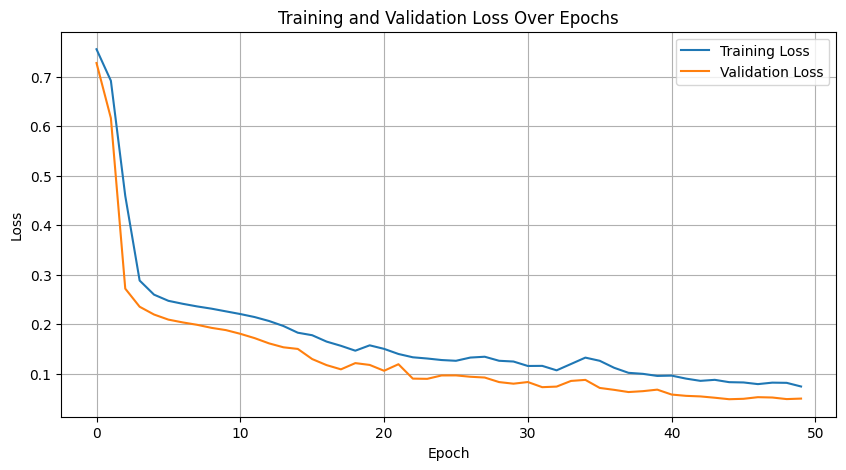

In [ ]:
# Plot Training and Validation Losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid()
plt.show()


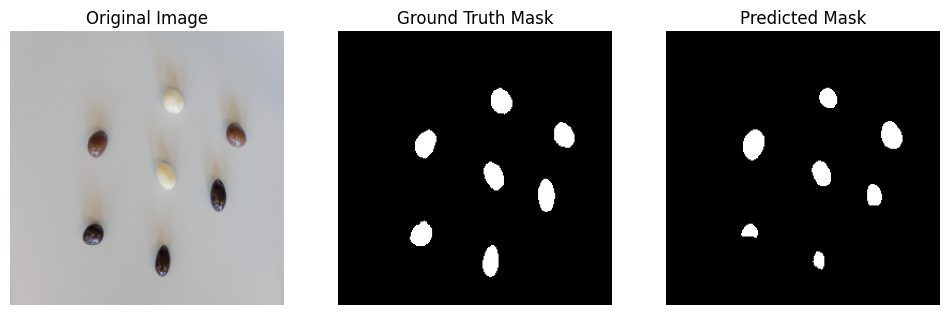

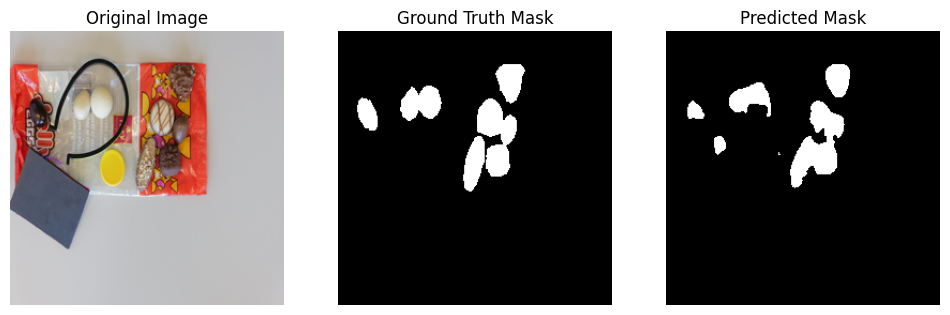

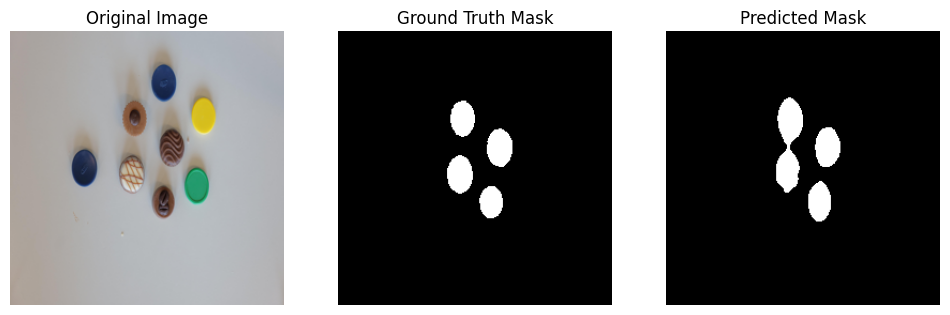

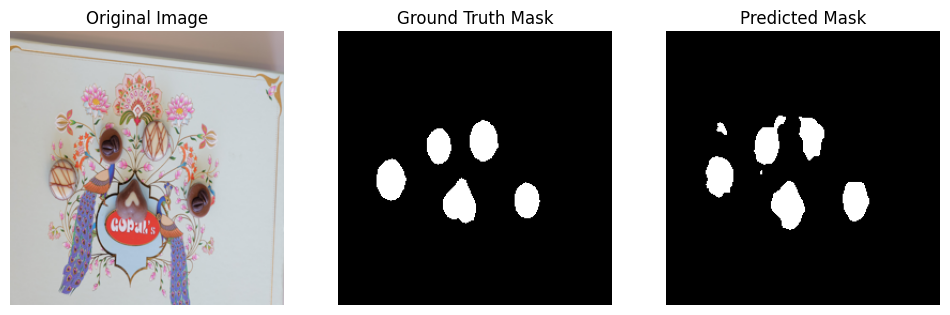

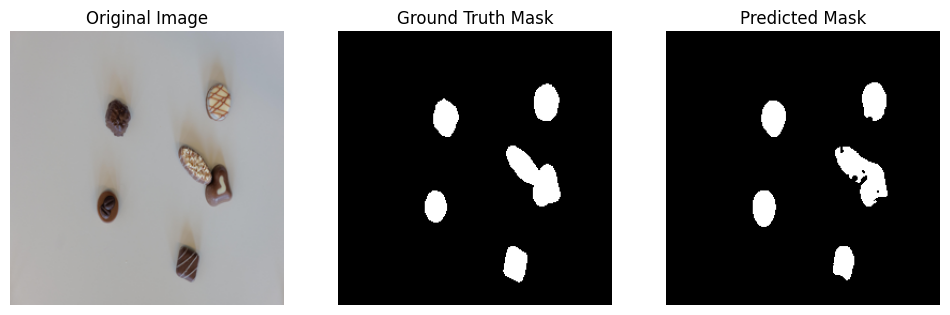

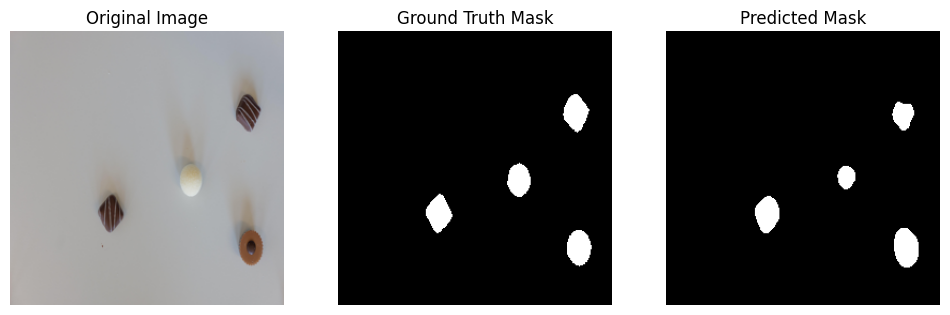

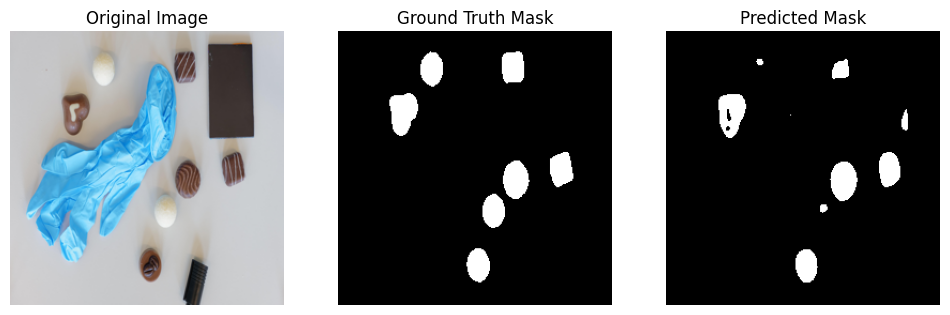

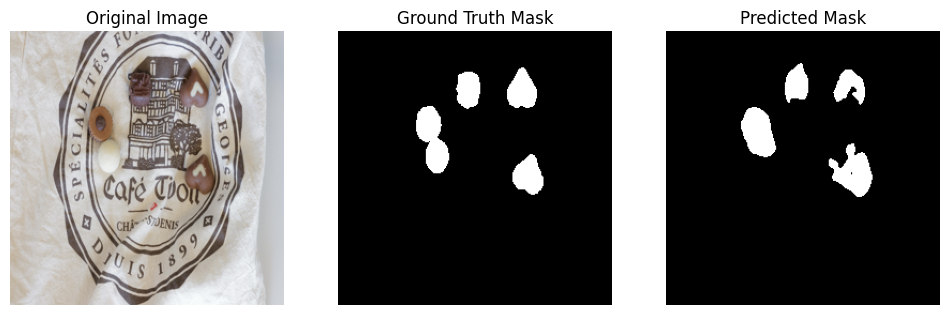

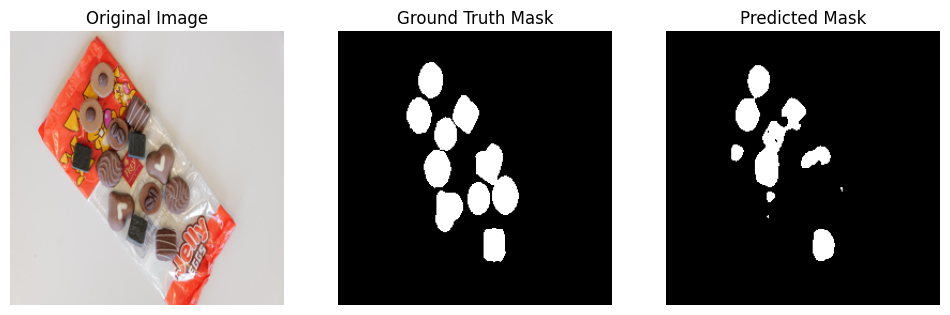

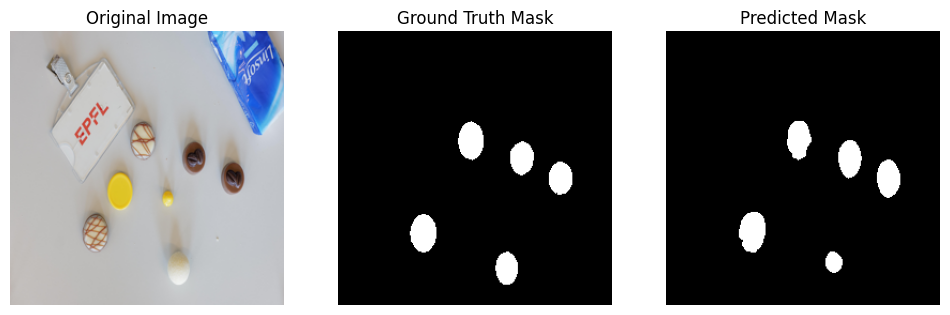

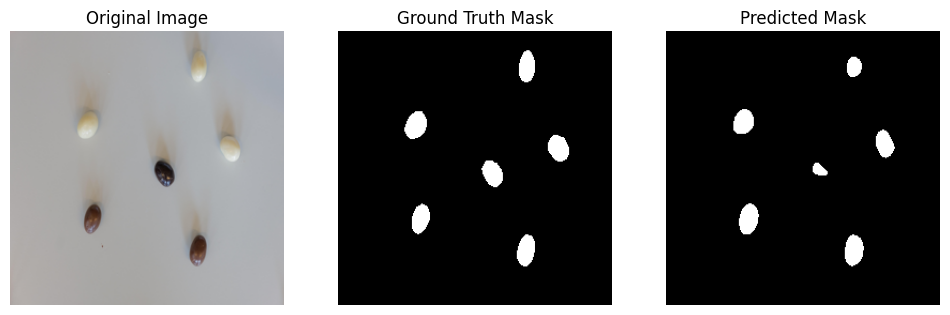

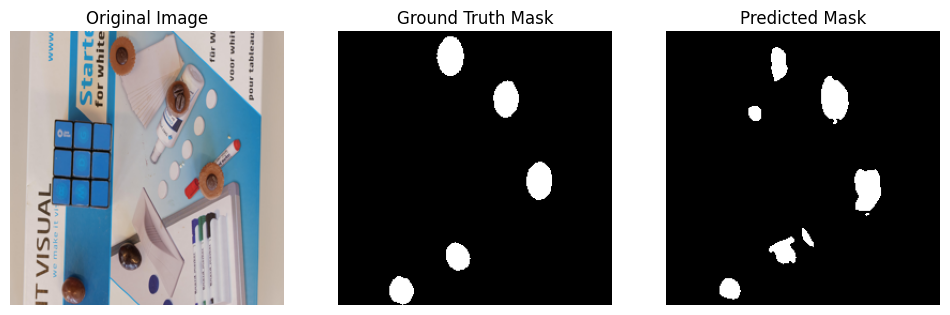

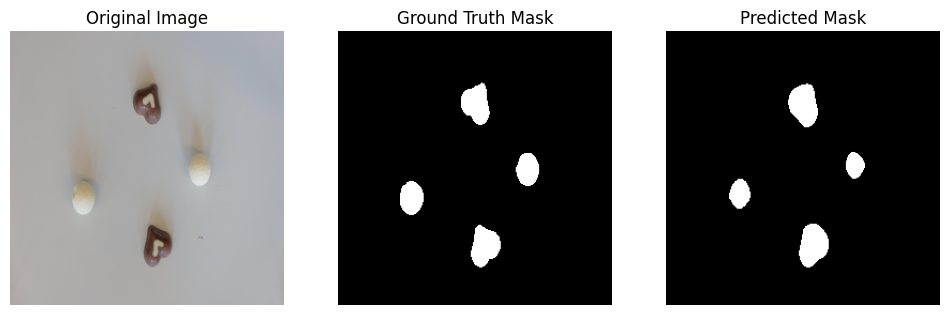

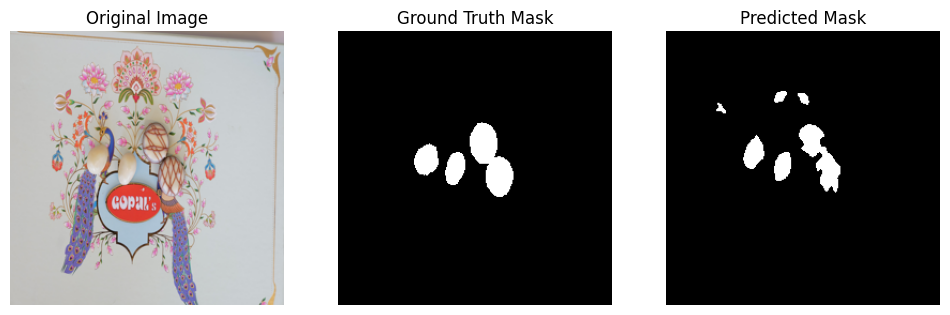

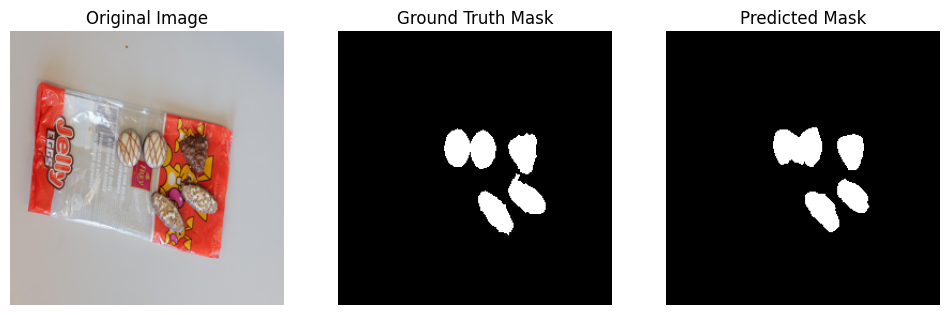

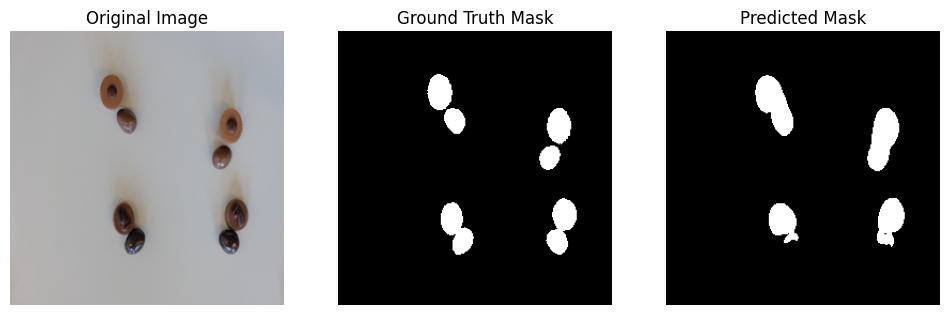

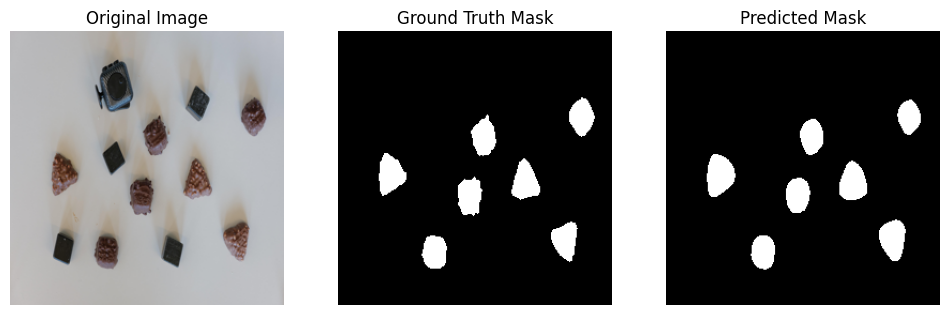

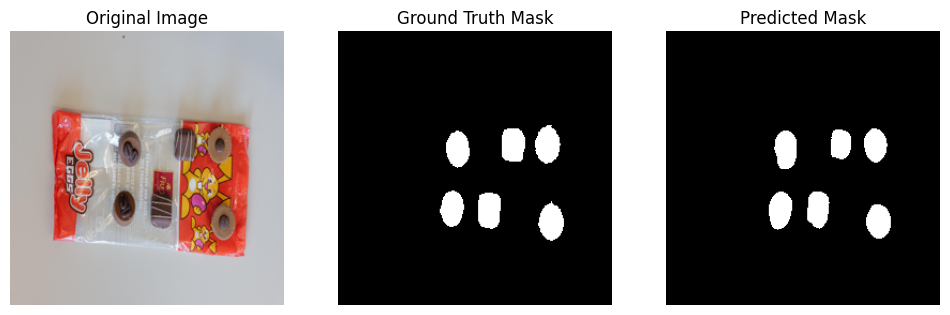

In [ ]:
# Visualize Predictions on Training Set
model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs) > 0.5  # Apply sigmoid and threshold at 0.5

        # Move data to CPU for visualization
        images = images.cpu()
        masks = masks.cpu()
        preds = preds.cpu()

        # Plot the first batch of images, ground truth masks, and predictions
        for i in range(len(images)):
            plt.figure(figsize=(12, 4))

            # Original Image
            plt.subplot(1, 3, 1)
            plt.imshow(images[i].permute(1, 2, 0))  # Convert CHW to HWC
            plt.title("Original Image")
            plt.axis("off")

            # Ground Truth Mask
            plt.subplot(1, 3, 2)
            plt.imshow(masks[i][0], cmap="gray")  # Plot the mask
            plt.title("Ground Truth Mask")
            plt.axis("off")

            # Predicted Mask
            plt.subplot(1, 3, 3)
            plt.imshow(preds[i][0], cmap="gray")  # Plot the predicted mask
            plt.title("Predicted Mask")
            plt.axis("off")

            plt.show()

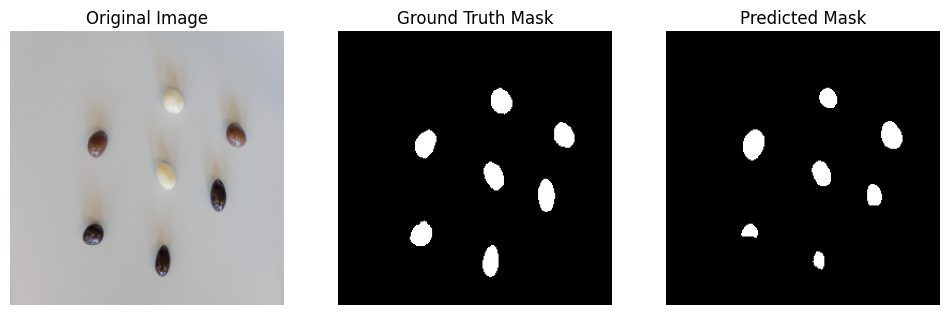

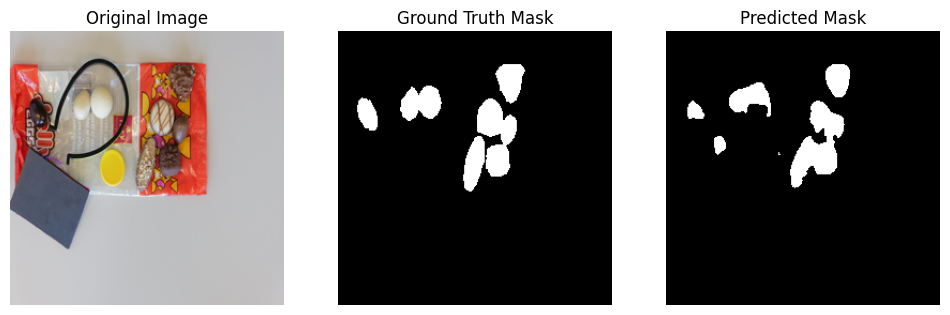

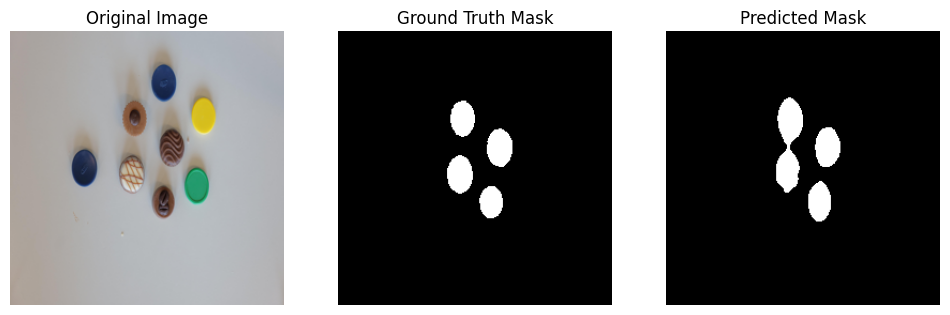

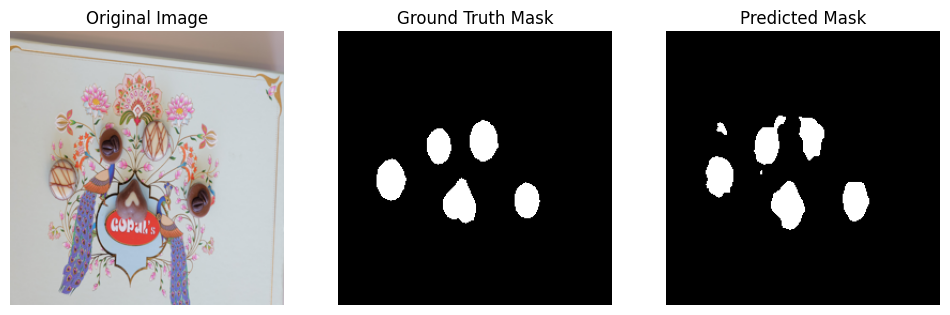

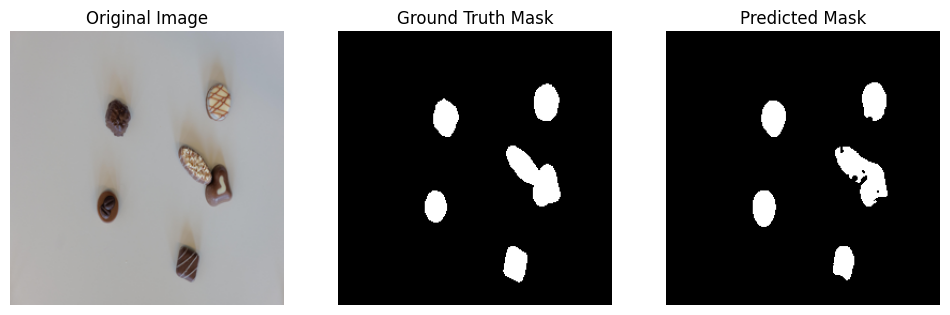

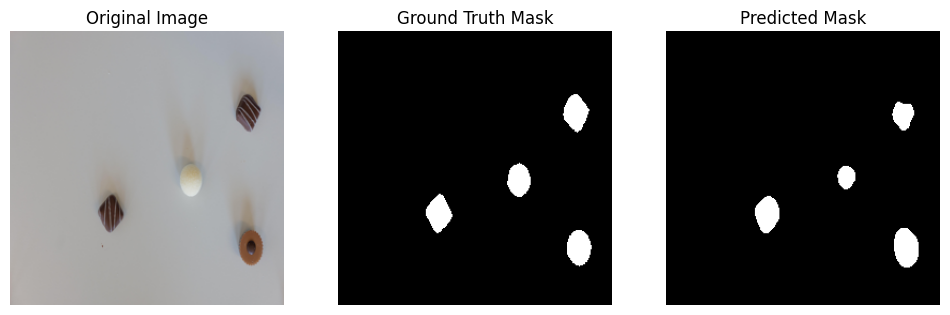

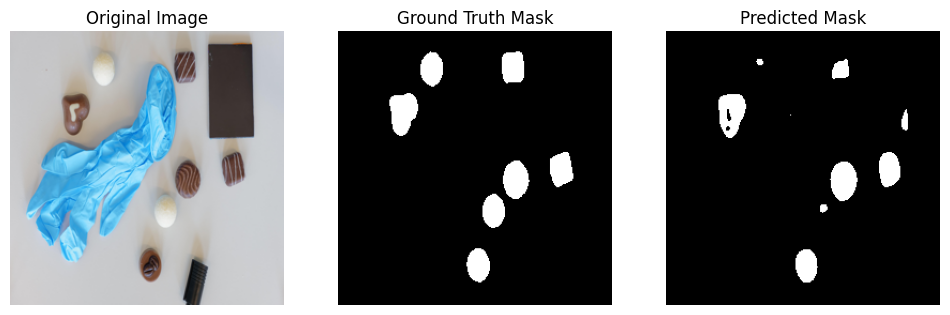

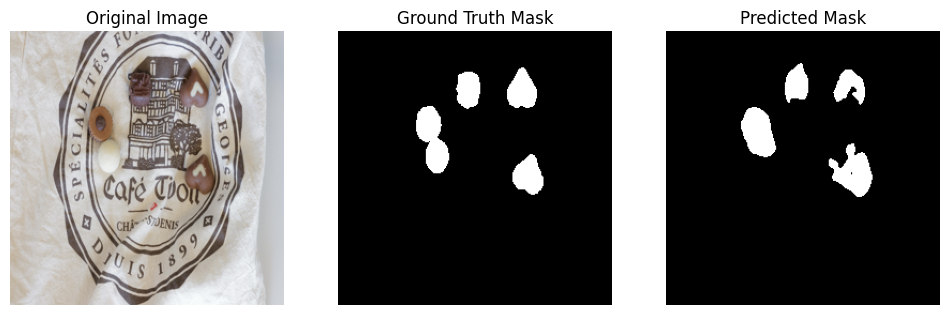

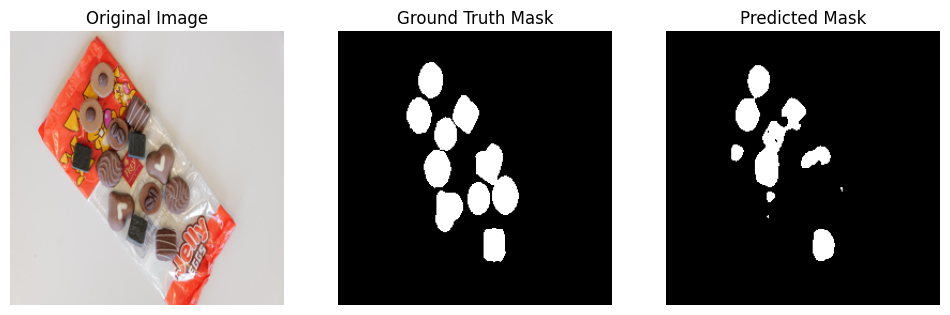

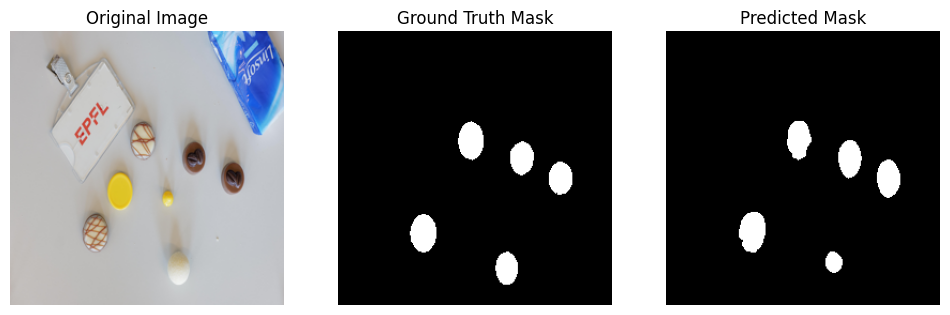

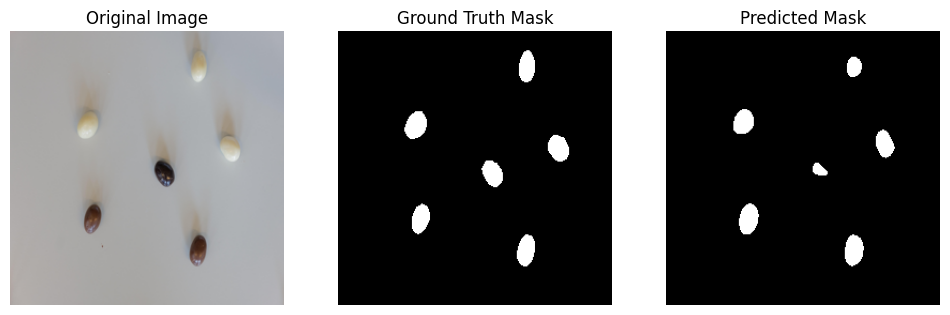

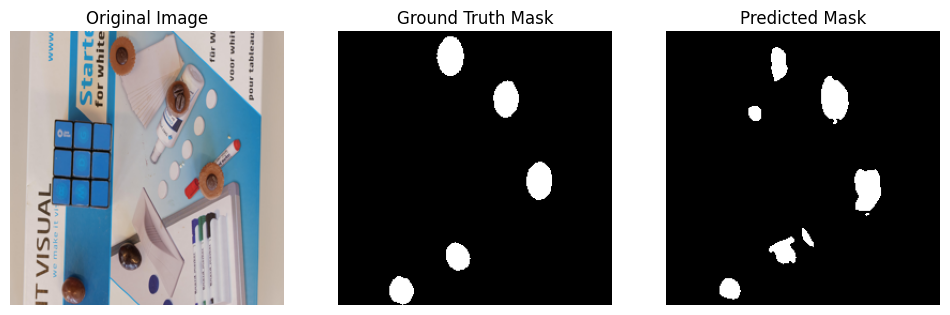

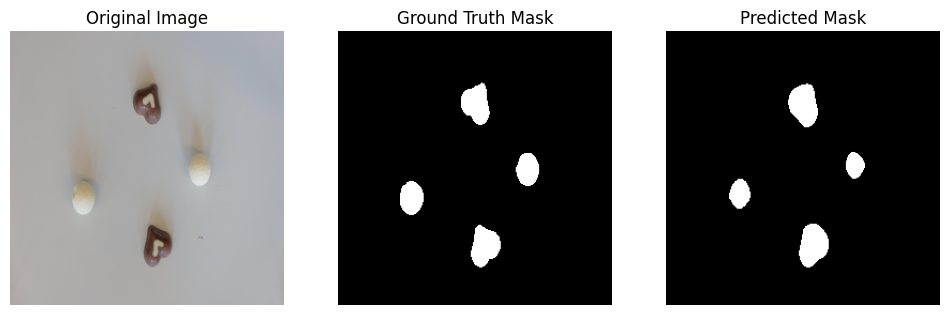

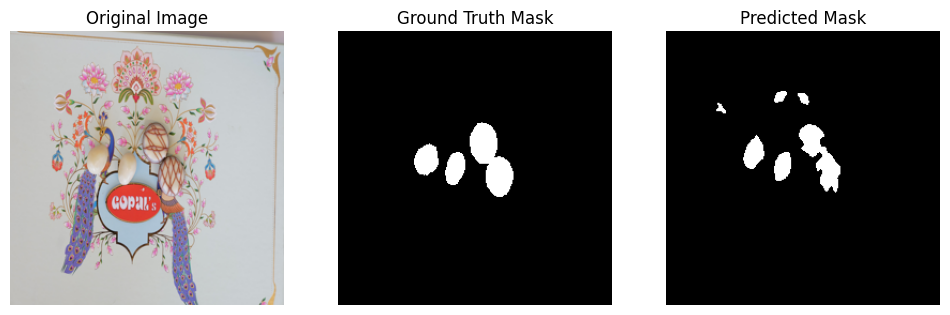

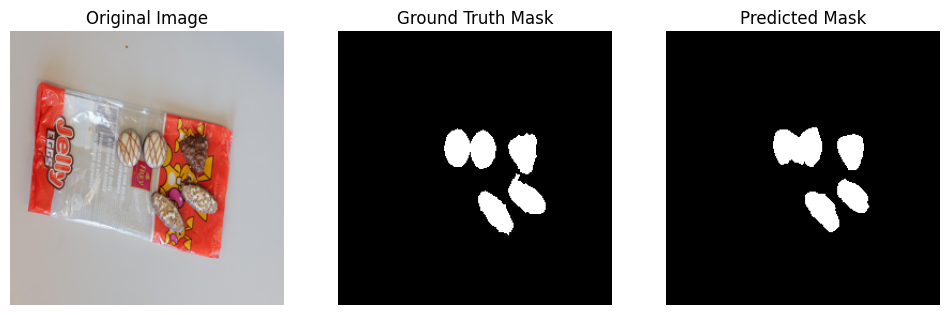

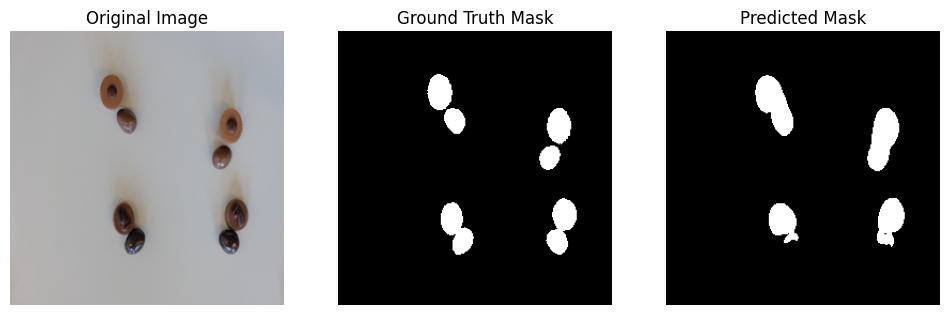

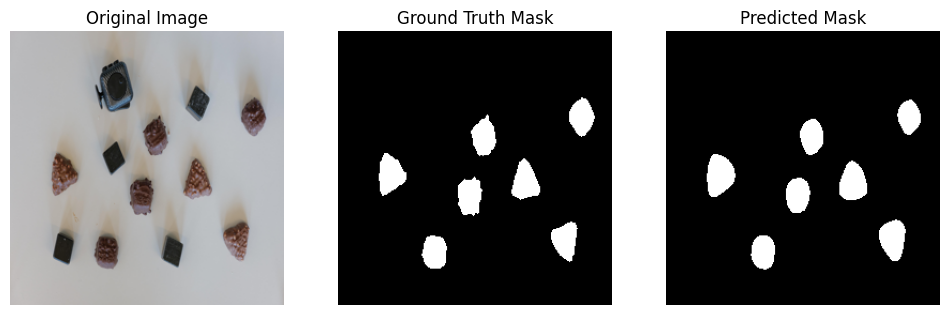

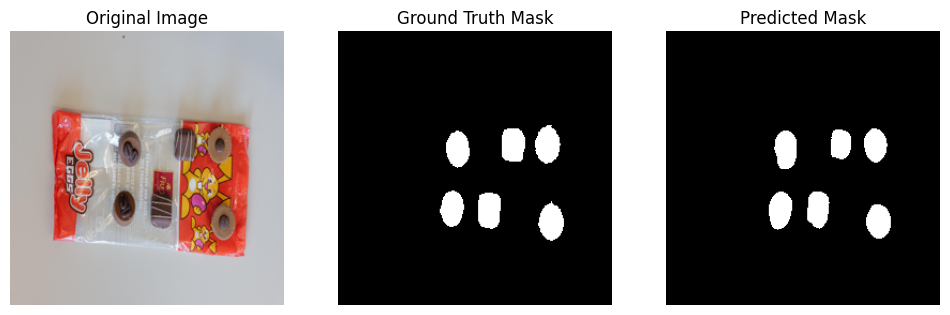

In [ ]:
# Visualize Predictions on Validation Set
model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs) > 0.5  # Apply sigmoid and threshold at 0.5

        # Move data to CPU for visualization
        images = images.cpu()
        masks = masks.cpu()
        preds = preds.cpu()

        # Plot the first batch of images, ground truth masks, and predictions
        for i in range(len(images)):
            plt.figure(figsize=(12, 4))

            # Original Image
            plt.subplot(1, 3, 1)
            plt.imshow(images[i].permute(1, 2, 0))  # Convert CHW to HWC
            plt.title("Original Image")
            plt.axis("off")

            # Ground Truth Mask
            plt.subplot(1, 3, 2)
            plt.imshow(masks[i][0], cmap="gray")  # Plot the mask
            plt.title("Ground Truth Mask")
            plt.axis("off")

            # Predicted Mask
            plt.subplot(1, 3, 3)
            plt.imshow(preds[i][0], cmap="gray")  # Plot the predicted mask
            plt.title("Predicted Mask")
            plt.axis("off")

            plt.show()